--- resim 1.jpeg : Solda Orijinal | Sağda 3x3 Ortalama Filtreli ---


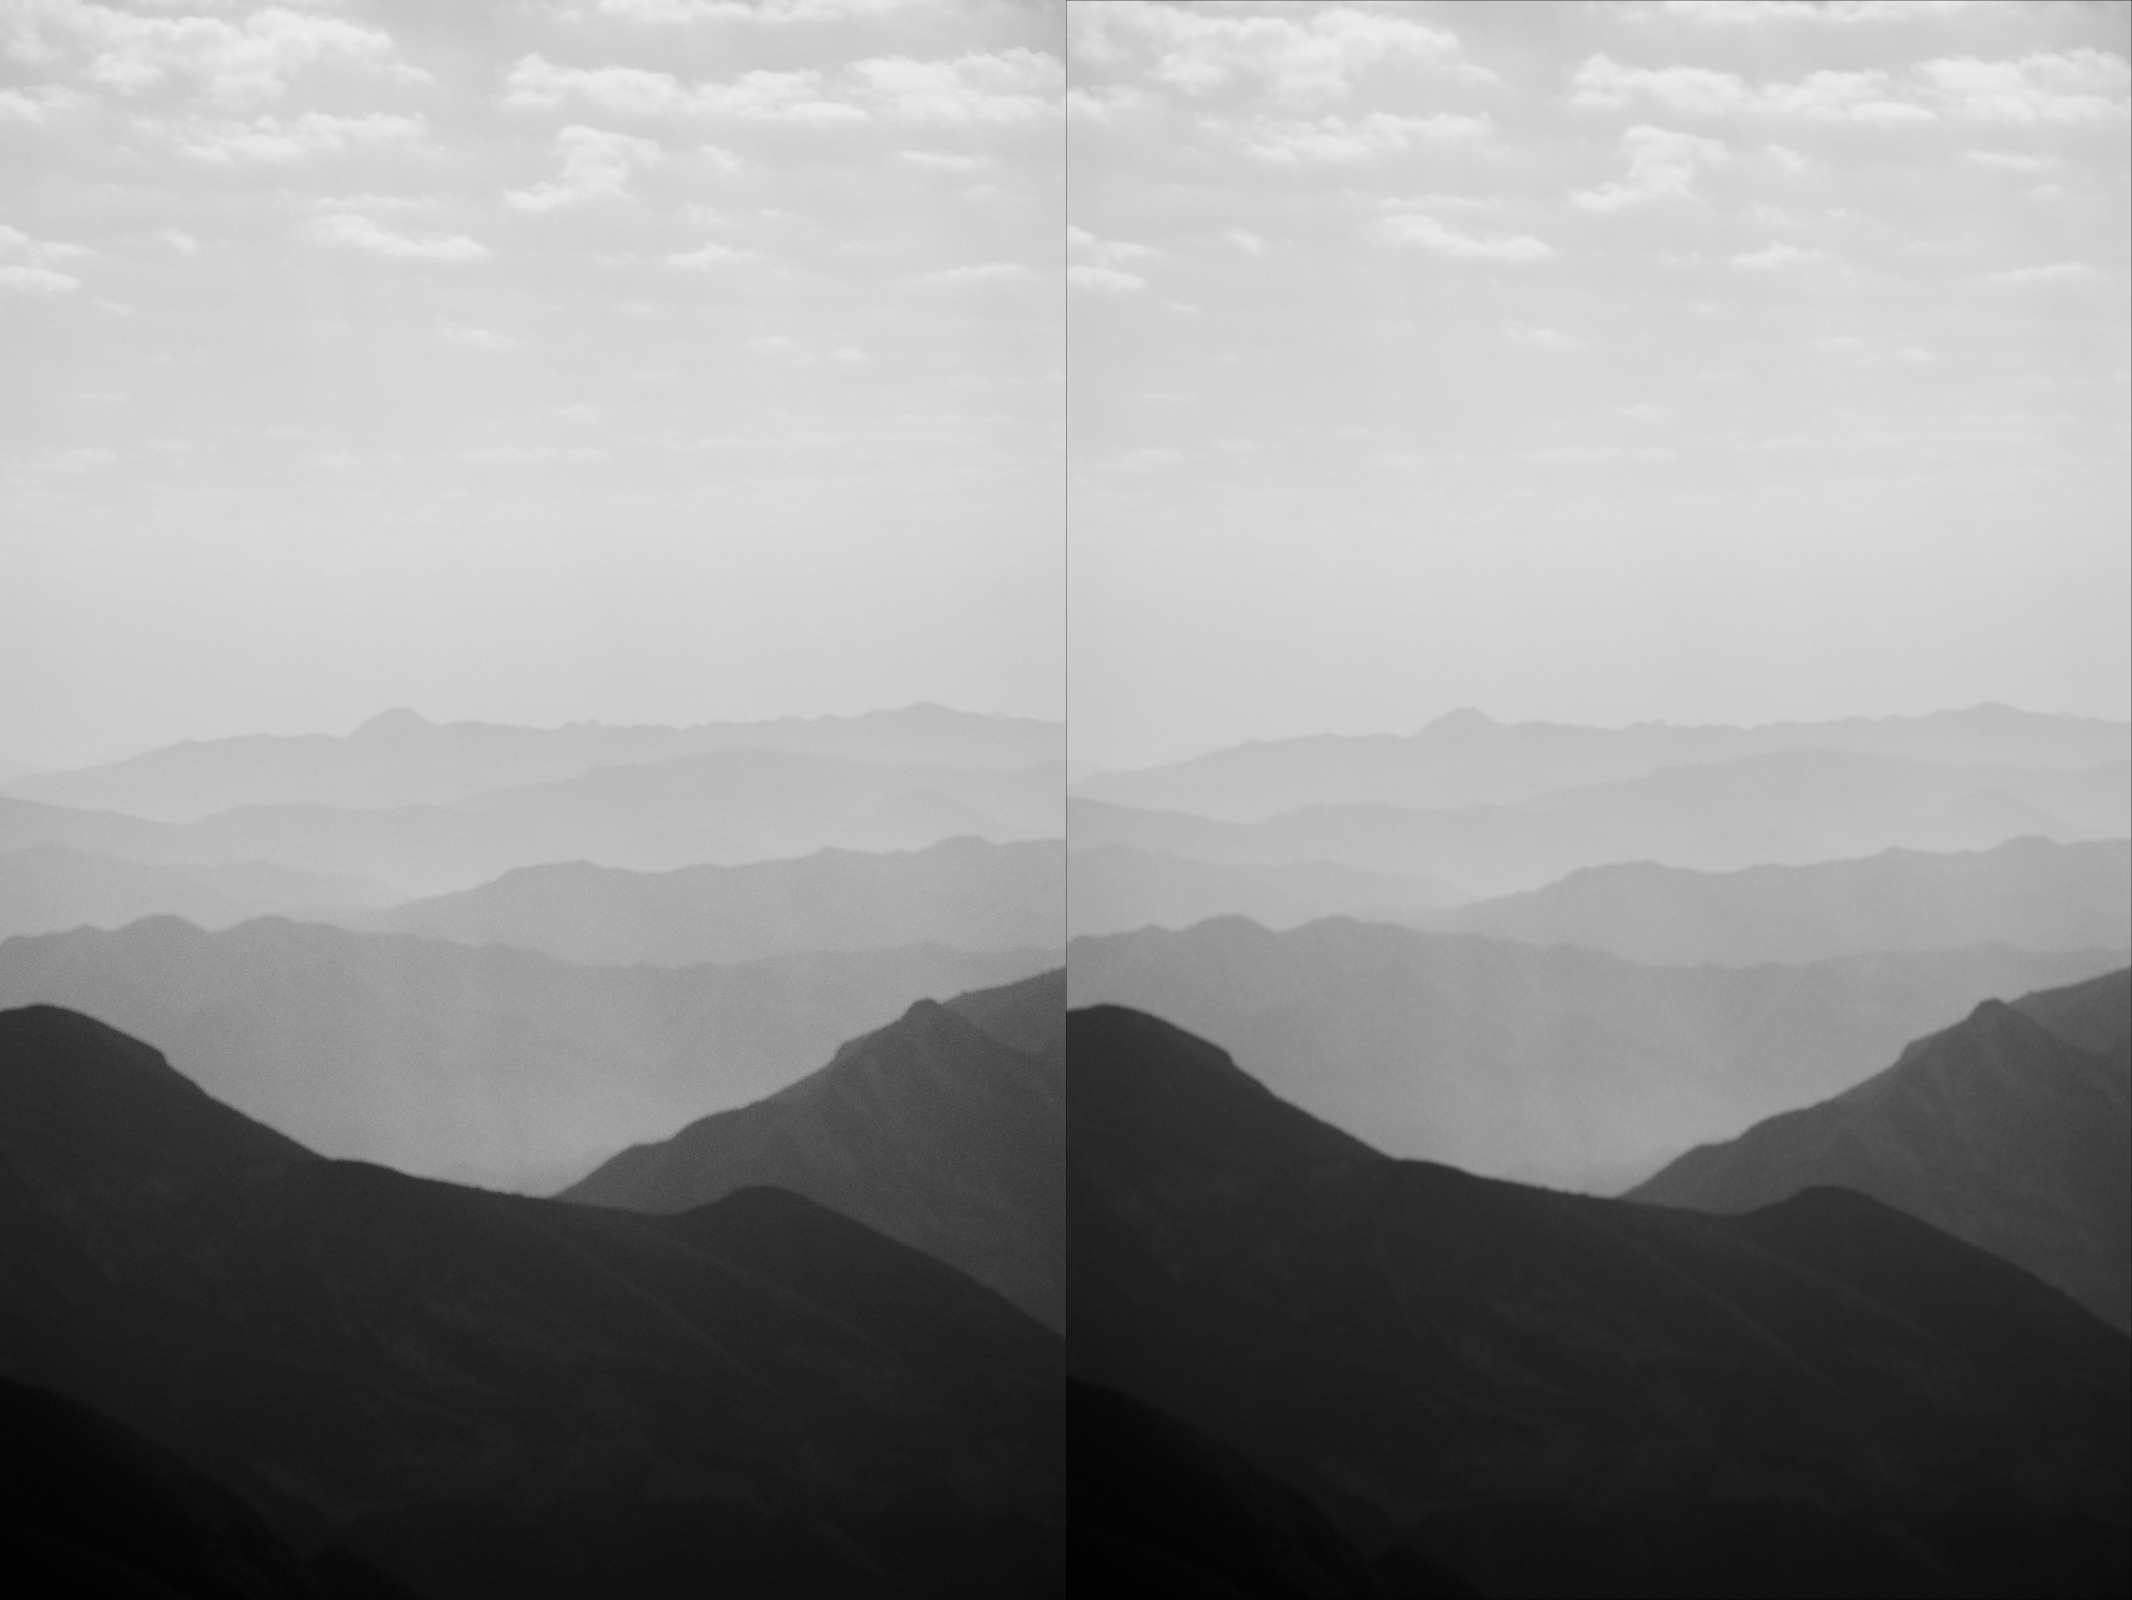

--- resim 2.jpeg : Solda Orijinal | Sağda 3x3 Ortalama Filtreli ---


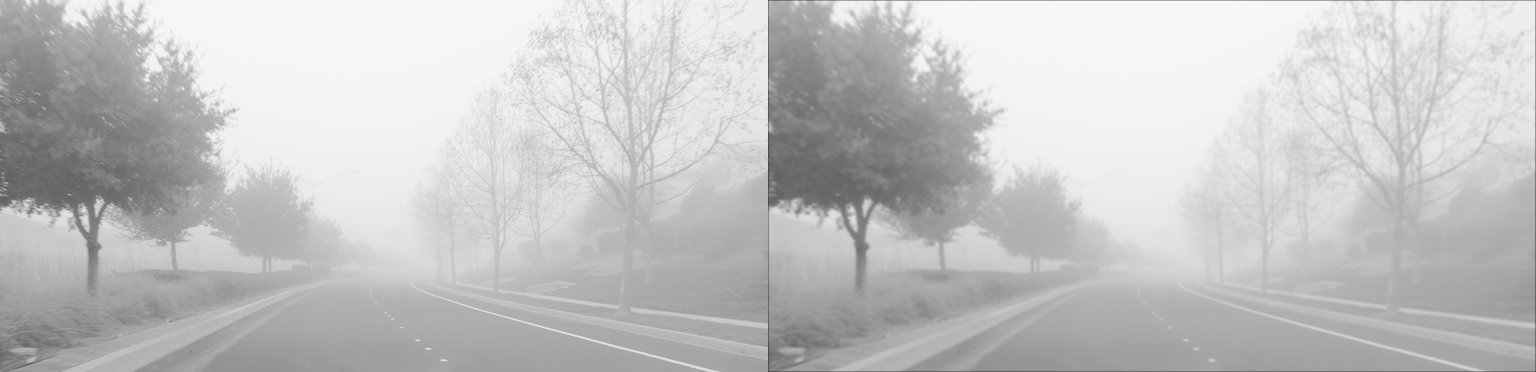

In [3]:
import os
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# 1. 3x3 ORTALAMA FİLTRESİ (Hazır fonksiyonsuz konvolüsyon)
def ortalama_filtresi_uygula(resim):
    h, w = resim.shape
    cikis = np.zeros((h, w), dtype=np.uint8)

    # Kenarlar için sıfır dolgusu (zero-padding)
    padli = np.zeros((h + 2, w + 2), dtype=np.float32)
    padli[1:h+1, 1:w+1] = resim

    # 3x3 Konvolüsyon döngüsü
    for i in range(h):
        for j in range(w):
            # Pikselin etrafındaki 3x3'lük komşuluğu al
            bolge = padli[i:i+3, j:j+3]
            # 9 pikselin toplamını alıp 9'a böl (ortalama)
            toplam = 0.0
            for r in range(3):
                for c in range(3):
                    toplam += bolge[r, c]

            cikis[i, j] = int((toplam / 9.0) + 0.5)

    return cikis

# 2. İKİ RESMİ İŞLE VE DOĞRUDAN EKRANA BAS
dosyalar = ["resim 1.jpeg", "resim 2.jpeg"]

for dosya in dosyalar:
    # Sol panelde veya kök dizindeki konumu kontrol et
    yol = f"/{dosya}" if os.path.exists(f"/{dosya}") else f"/content/{dosya}"

    if not os.path.exists(yol):
        print(f"Hata: {dosya} bulunamadı!")
        continue

    # Grayscale olarak oku
    orijinal = cv2.imread(yol, cv2.IMREAD_GRAYSCALE)

    # Filtre uygula
    temizlenmis = ortalama_filtresi_uygula(orijinal)

    # Diske kaydet
    cv2.imwrite(f"/content/bastirilmis_{dosya}", temizlenmis)

    # Ekrana doğrudan yan yana yapıştırarak göster
    print(f"--- {dosya} : Solda Orijinal | Sağda 3x3 Ortalama Filtreli ---")
    yan_yana = np.hstack((orijinal, temizlenmis))
    cv2_imshow(yan_yana)